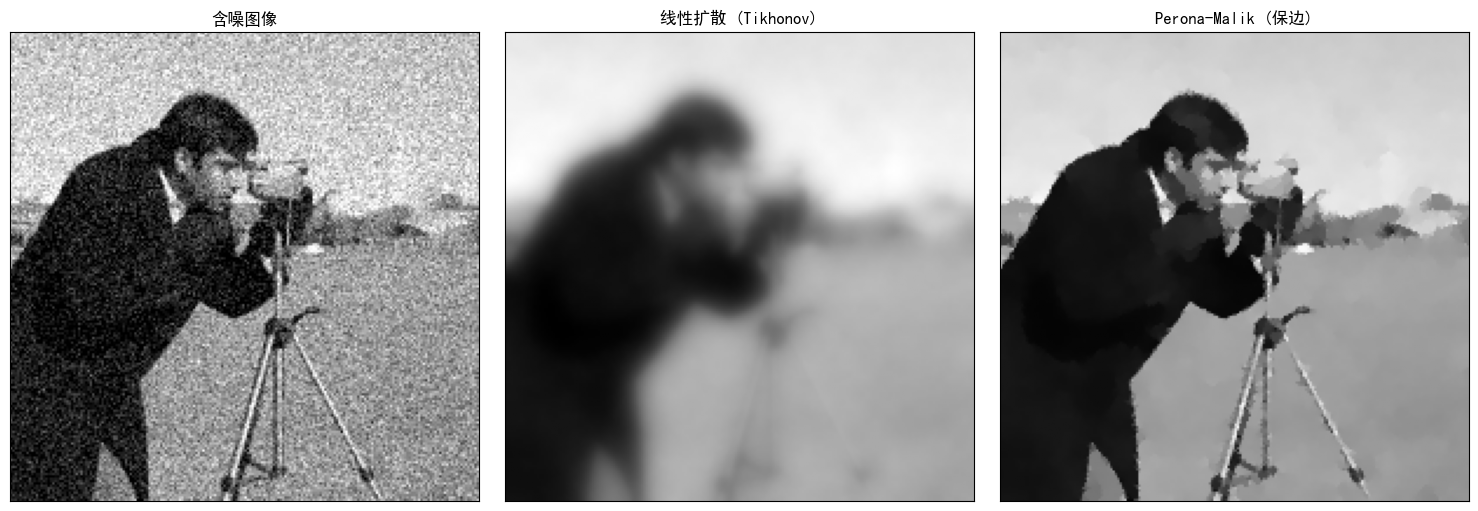

In [2]:
"""
实验2.4 Perona-Malik非线性扩散：保边去噪
对应章节：2.2 TV先验保边思想
知识点：非线性扩散；边缘保持；扩散系数在边缘处趋零

素材来源：
  - IP25 (variational_formulations.md): 线性扩散(热方程)去噪
  - IP26 (variational_formulations.md): Perona-Malik非线性扩散去噪
  代码逐行取自 IP25 + IP26 的 code-cell
"""

import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import random_noise
from skimage.transform import resize
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

# ====== 来源: IP25 + IP26 (variational_formulations.md) ======

# 参数 (IP25/IP26)
sigma = 0.1
alpha = 1
dt = 1e-6
niter = 1001
n = 200

# 扩散算子 (IP25/IP26: 支持 c(s) = 1 或 c(s) = 1/(1+1e6*s))
def L(u, coeff=lambda s: 1):
    """扩散算子 (来源: IP25/IP26 variational_formulations.md)"""
    ue = np.pad(u, 1, mode='edge')

    # 扩散系数 (中心差分计算梯度模)
    grad_norm = ((ue[2:, 1:-1] - ue[:-2, 1:-1]) / (2 / n))**2 + \
                ((ue[1:-1, 2:] - ue[1:-1, :-2]) / (2 / n))**2
    c = np.pad(coeff(grad_norm), 1, mode='edge')

    # 扩散项 (前向+后向差分组合)
    uxx = ((c[1:-1, 1:-1] + c[2:, 1:-1]) * (ue[2:, 1:-1] - ue[1:-1, 1:-1]) -
           (c[:-2, 1:-1] + c[1:-1, 1:-1]) * (ue[1:-1, 1:-1] - ue[:-2, 1:-1])) / (2 / n**2)
    uyy = ((c[1:-1, 1:-1] + c[1:-1, 2:]) * (ue[1:-1, 2:] - ue[1:-1, 1:-1]) -
           (c[1:-1, :-2] + c[1:-1, 1:-1]) * (ue[1:-1, 1:-1] - ue[1:-1, :-2])) / (2 / n**2)

    return uxx + uyy

# 含噪图像 (IP25/IP26)
f = resize(data.camera(), (n, n))
f_delta = random_noise(f, var=sigma**2)

# 线性扩散 (IP25: coeff = lambda s: 1 + 0*s)
u_linear = np.zeros((n, n))
for k in range(niter - 1):
    u_linear = u_linear - dt * (u_linear - alpha * L(u_linear, lambda s: 1 + 0 * s)) + dt * f_delta

# Perona-Malik 扩散 (IP26: coeff = lambda s: 1/(1+1e6*s))
u_pm = np.zeros((n, n))
for k in range(niter - 1):
    u_pm = u_pm - dt * (u_pm - alpha * L(u_pm, lambda s: 1 / (1 + 1e6 * s))) + dt * f_delta

# ====== 可视化 (IP25/IP26 风格) ======
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(f_delta, cmap='gray')
ax[0].set_title('含噪图像')
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].imshow(u_linear, cmap='gray')
ax[1].set_title('线性扩散 (Tikhonov)')
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[2].imshow(u_pm, cmap='gray')
ax[2].set_title('Perona-Malik (保边)')
ax[2].set_xticks([])
ax[2].set_yticks([])

plt.tight_layout()
plt.savefig('2_4_result.png', dpi=150, bbox_inches='tight')
plt.show()
